In [1]:

# PROJET_DIT

# %% Importation des bibliothèques
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import joblib

In [2]:

# %% Chargement des données
data = pd.read_excel("DDDIEMMME.xlsx", sheet_name="Feuil2")


In [3]:
# Nettoyage
numeric_cols = data.select_dtypes(include=np.number).columns
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].median())
data.drop_duplicates(inplace=True)

In [4]:
# Encodage simple (LabelEncoder ou OneHot selon besoin)
from sklearn.preprocessing import LabelEncoder, StandardScaler
label_encoder = LabelEncoder()
for col in data.select_dtypes(include=['object']).columns:
    data[col] = label_encoder.fit_transform(data[col].astype(str))

scaler = StandardScaler()
data[data.select_dtypes(include=['float', 'int']).columns] = scaler.fit_transform(
    data.select_dtypes(include=['float', 'int'])
)


In [5]:

# %% Définition de la cible insécurité alimentaire
def definir_insécurité_alimentaire(row):
    if sum(row[col] > 1.5 for col in [
        'q605_1_ne_plus_avoir_de_nourriture_pas_suffisamment_d_argent',
        'q606_1_avoir_faim_mais_ne_pas_manger',
        'q607_1_passer_toute_une_journee_sans_manger'
    ]) >= 1:
        return 2
    elif sum(0 < row[col] <= 1.5 for col in [
        'q600_inquiets_de_ne_pas_avoir_suffisamment_de_nourriture',
        'q601_ne_pas_manger_nourriture_saine_nutritive',
        'q602_manger_nourriture_peu_variee',
        'q603_sauter_un_repas',
        'q604_manger_moins_que_ce_que_vous_auriez_du'
    ]) >= 2:
        return 1
    else:
        return 0

data['insécurité_alimentaire'] = data.apply(definir_insécurité_alimentaire, axis=1)

# Sauvegarde avec la colonne incluse
data.to_csv("data_encoded_1.csv", index=False)

In [6]:
# Filtrer modérée/sévère
data_filtrée = data[data['insécurité_alimentaire'].isin([1, 2])]

X = data_filtrée.drop(columns=['insécurité_alimentaire'])
y = data_filtrée['insécurité_alimentaire'].replace({1: 0, 2: 1})

In [7]:
# %% Division train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# %% Entraînement RandomForest
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    min_samples_leaf=10,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train, y_train)

from sklearn.metrics import classification_report

# Prédictions sur le jeu de test
rf_preds = rf.predict(X_test)
print("rf_preds:", rf_preds[:20])

# Rapport de classification
print("📊 Rapport RandomForest :")
print(classification_report(y_test, rf_preds))


rf_preds: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1]
📊 Rapport RandomForest :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       439
           1       1.00      0.98      0.99        81

    accuracy                           1.00       520
   macro avg       1.00      0.99      0.99       520
weighted avg       1.00      1.00      1.00       520



✅ Comparaison des 5 variables les plus importantes :
                                RandomForest_feature  RandomForest_importance
0      q601_ne_pas_manger_nourriture_saine_nutritive                 0.062054
1                               q603_sauter_un_repas                 0.083059
2               q606_1_avoir_faim_mais_ne_pas_manger                 0.096366
3  q605_1_ne_plus_avoir_de_nourriture_pas_suffisa...                 0.118685
4        q604_manger_moins_que_ce_que_vous_auriez_du                 0.128681


C:\Users\HP\AppData\Local\Temp\ipykernel_28260\425717912.py:23: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


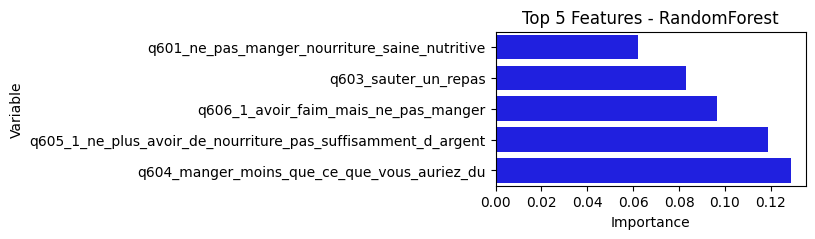

In [9]:
# 🔍 Extraire les importances
rf_importances = rf.feature_importances_
rf_top5_idx = np.argsort(rf_importances)[-5:]
rf_top5_features = X_train.columns[rf_top5_idx]
rf_top5_values = rf_importances[rf_top5_idx]

# 🔍 Construire DataFrame comparatif
df_top5 = pd.DataFrame({
    "RandomForest_feature": rf_top5_features,
    "RandomForest_importance": rf_top5_values
})

print("✅ Comparaison des 5 variables les plus importantes :")
print(df_top5)


# 🔹 Graphique
plt.figure(figsize=(4, 2))
sns.barplot(x=rf_top5_values, y=rf_top5_features, color="blue")
plt.title("Top 5 Features - RandomForest")
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

In [10]:
# Sélection des features importantes
importances = rf.feature_importances_
indices_top5 = np.argsort(importances)[-5:]
selected_features = X_train.columns[indices_top5].tolist()

print("✅ Variables retenues :", selected_features)


✅ Variables retenues : ['q601_ne_pas_manger_nourriture_saine_nutritive', 'q603_sauter_un_repas', 'q606_1_avoir_faim_mais_ne_pas_manger', 'q605_1_ne_plus_avoir_de_nourriture_pas_suffisamment_d_argent', 'q604_manger_moins_que_ce_que_vous_auriez_du']


In [11]:
# Réentraînement avec les 5 features
rf_selected = RandomForestClassifier(n_estimators=100, random_state=42)
rf_selected.fit(X_train[selected_features], y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [12]:
# Sauvegarde du modèle
joblib.dump({"model": rf_selected, "features": selected_features}, "modele_food_insecurity_best.pkl")
print("✅ Modèle sauvegardé avec succès")


✅ Modèle sauvegardé avec succès


In [13]:
# %% Prédiction exemple
bundle = joblib.load("modele_food_insecurity_best.pkl")
model = bundle["model"]
selected_features = bundle["features"]
print("", selected_features)


 ['q601_ne_pas_manger_nourriture_saine_nutritive', 'q603_sauter_un_repas', 'q606_1_avoir_faim_mais_ne_pas_manger', 'q605_1_ne_plus_avoir_de_nourriture_pas_suffisamment_d_argent', 'q604_manger_moins_que_ce_que_vous_auriez_du']


In [14]:

# Construire new_data avec exactement les colonnes attendues
data_dict = {col: 0 for col in selected_features}  # valeurs par défaut
data_dict.update({
    "q600_inquiets_de_ne_pas_avoir_suffisamment_de_nourriture": 2,
    "q601_ne_pas_manger_nourriture_saine_nutritive": 3,
    "q602_manger_nourriture_peu_variee": 2,
    "q603_sauter_un_repas": 1,
    "q604_manger_moins_que_ce_que_vous_auriez_du": 2,
    "q605_1_ne_plus_avoir_de_nourriture_pas_suffisamment_d_argent": 0,
    "q606_1_avoir_faim_mais_ne_pas_manger": 1,
    "q607_1_passer_toute_une_journee_sans_manger": 2
})

new_data = pd.DataFrame([data_dict])[selected_features]

prediction = model.predict(new_data)[0]
proba = model.predict_proba(new_data)[0][1]

mapping = {
    0: "Insécurité alimentaire modérée",
    1: "Insécurité alimentaire sévère"
}
print("🎯 Résultat :", mapping[prediction])
print("📊 Probabilité :", round(proba, 3))


🎯 Résultat : Insécurité alimentaire modérée
📊 Probabilité : 0.13
